In [ ]:
## Import libraries
from IPython.display import clear_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from functools import reduce
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Color Mapping for Mustard Genotypes
color = { 
    'SGC': '#7f7f7f',   # Gray
    'FLB': '#1f77b4',   # Blue
    'CAB': '#ff7f0e',   # Orange
    } 

## Directories
DIR_GatorLeaf_LA = "/Users/JeanPompeo/Documents/PhD/Data/Leaf_Area/GatorLeaf/GL_Leaf_Area.csv"
DIR_GatorLeaf_LW = "/Users/JeanPompeo/Documents/PhD/Data/Leaf_Area/GatorLeaf/GL_Leaf_Width.csv"
DIR_GatorLeaf_LL = "/Users/JeanPompeo/Documents/PhD/Data/Leaf_Area/GatorLeaf/GL_Leaf_Length.csv"
DIR_GatorLeaf_LD = "/Users/JeanPompeo/Documents/PhD/Data/Leaf_Area/GatorLeaf/GL_Leaf_Distribution.csv"
DIR_ImageJ_LD = "/Users/JeanPompeo/Documents/PhD/Data/Leaf_Area/ImageJ/IJ_Leaf_Distribution.csv"
DIR_Out_LA = "/Users/JeanPompeo/Documents/PhD/Data/Outputs/Leaf_Area"

## Clear the output
clear_output()

### MERGE DATA ###

In [ ]:
# Function to transpose L1, L2, ... Ln columns into vertical format
def transpose_leaf_area_columns(DF, VAR, SOURCE):
    """
    Transposes columns labelled L1, L2, ..., Ln into a column 'Leaf Area',
    keeps 'Leaf Number' (L1, L2, ...) and groups by 'File' and 'Source'.
    Args:
        df (pd.DataFrame): DataFrame with wide leaf area columns.
    Returns:
        pd.DataFrame: Long-format DataFrame with columns ['File', 'Source', 'Leaf Number', 'Leaf Area']
    """

    # Read CSV file and change variable types
    DF_1 = pd.read_csv(DF)
    DF_1['Sample_Num'] = DF_1['Sample_Num'].astype(int)
    DF_1['Cultivar'] = DF_1['Cultivar'].astype(str)

    # Drop unecessary columns from DF
    columns_to_drop = ['New_File', 'Date', 'Exp_ID', 'Exp_Num', 'Date_Analyzed']
    DF_2 = DF_1.drop(columns=columns_to_drop, errors='ignore')


    # Identify leaf columns (L1, L2, ...)
    leaf_cols = [col for col in DF_2.columns if col.startswith('L') and col[1:].isdigit()]

    # Melt the DataFrame
    DF_long = DF_2.melt(
        id_vars=[col for col in DF_2.columns if col not in leaf_cols],
        value_vars=leaf_cols,
        var_name='Leaf_Num',
        value_name=VAR
    )

    # Add Source Column 
    DF_long['Source'] = SOURCE

    # Optional: drop NaN leaf areas
    DF_long = DF_long.dropna(subset=VAR)
    DF_long = DF_long.sort_values(by = ['File', VAR], ascending=[True, False])

    return DF_long


Gator_LD_long = transpose_leaf_area_columns(DIR_GatorLeaf_LD, "Leaf_Area", "GatorLeaf")
Gator_LW_long = transpose_leaf_area_columns(DIR_GatorLeaf_LW, "Leaf_Width", "GatorLeaf")
Gator_LL_long = transpose_leaf_area_columns(DIR_GatorLeaf_LL, "Leaf_Length", "GatorLeaf")
ImageJ_LD_long = transpose_leaf_area_columns(DIR_ImageJ_LD, "Leaf_Area", "ImageJ")

#Gator_LD_long.head()
#Gator_LL_long.head()
#Gator_LW_long.head()
ImageJ_LD_long.head()

,File,Cultivar,Sample_Num,Leaf_Num,Leaf_Area,Source
0,2025-12-11_GH34_CAB_004.jpg,CAB,4,L1,327.965,ImageJ
12,2025-12-11_GH34_CAB_004.jpg,CAB,4,L2,296.155,ImageJ
24,2025-12-11_GH34_CAB_004.jpg,CAB,4,L3,267.493,ImageJ
36,2025-12-11_GH34_CAB_004.jpg,CAB,4,L4,184.097,ImageJ
48,2025-12-11_GH34_CAB_004.jpg,CAB,4,L5,101.032,ImageJ


In [ ]:
# Combine all leaf area files to merge on specific shared columns

def combine_leaf_area_files(DF1, DF2, DF3, DF4, OUTPUT):
    """
    Combines GatorLeaf, ImageJ, GatorLeaf Width, and GatorLeaf Length CSVs by shared columns:
    File, Cultivar, Sample_Num, and Leaf_Num.
    Returns:
        pd.DataFrame: Combined DataFrame.
    """

    # Merge Leaf Distribution df on specified shared columns
    shared_cols = ['File', 'Cultivar', 'Sample_Num', 'Leaf_Num', 'Source', 'Leaf_Area']
    DF = [DF1, DF2]
    DF_combined = reduce(lambda left, right: pd.merge(left, right, on=shared_cols, how='outer'), DF)

    # Merge combined leaf distribution DF with others on specified shared columns
    shared_cols = ['File', 'Cultivar', 'Sample_Num', 'Leaf_Num', 'Source']
    All_DF = [DF3, DF4, DF_combined]
    combined_DF = reduce(lambda left, right: pd.merge(left, right, on=shared_cols, how='outer'), All_DF)

    # Remove the "L" from Leaf_Num
    combined_DF['Leaf_Num'] = combined_DF['Leaf_Num'].astype(str).str.replace(r'^L', '', regex=True)
    combined_DF['Leaf_Num'] = combined_DF['Leaf_Num'].astype(int)

    # Multiply Width x Length
    combined_DF['LxW'] = combined_DF['Leaf_Length'] * combined_DF['Leaf_Width']

    combined_DF.to_csv(os.path.join(OUTPUT + "Leaf_Area_Combined.csv"), index=False)

    return combined_DF

# Example usage:
combined_df = combine_leaf_area_files(Gator_LD_long, ImageJ_LD_long, Gator_LW_long, Gator_LL_long, DIR_Out_LA)

# Reduced DF
GatorLeaf_df = combined_df[combined_df["Source"] == "GatorLeaf"]
ImageJ_df = combined_df[combined_df["Source"] == "ImageJ"]

combined_df.head()

,File,Cultivar,Sample_Num,Leaf_Num,Leaf_Width,Source,Leaf_Length,Leaf_Area,LxW
0,2025-12-11_GH34_CAB_004.jpg,CAB,4,1,NaN,ImageJ,NaN,327.965,NaN
1,2025-12-11_GH34_CAB_004.jpg,CAB,4,10,NaN,ImageJ,NaN,2.187,NaN
2,2025-12-11_GH34_CAB_004.jpg,CAB,4,11,NaN,ImageJ,NaN,1.269,NaN
3,2025-12-11_GH34_CAB_004.jpg,CAB,4,12,NaN,ImageJ,NaN,0.276,NaN
4,2025-12-11_GH34_CAB_004.jpg,CAB,4,13,NaN,ImageJ,NaN,0.089,NaN


In [ ]:
# Reduce df to only necessary values for Statistics
columns_to_keep = ['Leaf_Num', 'Sample_Num', 'Cultivar', 'Leaf_Area', 'Source']
reduced_df = combined_df[columns_to_keep].copy()

GatorLeaf_LA = reduced_df[reduced_df["Source"] == "GatorLeaf"]
GatorLeaf_LA = GatorLeaf_LA.drop(columns='Source')
GatorLeaf_LA = GatorLeaf_LA.rename(columns={'Leaf_Area': 'GatorLeaf'})

ImageJ_LA = reduced_df[reduced_df["Source"] == "ImageJ"]
ImageJ_LA = ImageJ_LA.drop(columns='Source')
ImageJ_LA = ImageJ_LA.rename(columns={'Leaf_Area': 'ImageJ'})

Stats_LA = pd.merge(GatorLeaf_LA, ImageJ_LA, on=["Leaf_Num", "Sample_Num", "Cultivar"])

Stats_LA['Difference'] = Stats_LA['GatorLeaf'] - Stats_LA['ImageJ']
Stats_LA['Avg'] = (Stats_LA['GatorLeaf'] + Stats_LA['ImageJ']) / 2

GatorLeaf_X = Stats_LA['GatorLeaf']
ImageJ_Y = Stats_LA['ImageJ']

GatorLeaf_X_FLB = Stats_LA[Stats_LA["Cultivar"] == "FLB"]['GatorLeaf'].reset_index(drop=True)
ImageJ_Y_FLB = Stats_LA[Stats_LA["Cultivar"] == "FLB"]['ImageJ'].reset_index(drop=True)
GatorLeaf_X_CAB = Stats_LA[Stats_LA["Cultivar"] == "CAB"]['GatorLeaf'].reset_index(drop=True)
ImageJ_Y_CAB = Stats_LA[Stats_LA["Cultivar"] == "CAB"]['ImageJ'].reset_index(drop=True)
GatorLeaf_X_SGC = Stats_LA[Stats_LA["Cultivar"] == "SGC"]['GatorLeaf'].reset_index(drop=True)
ImageJ_Y_SGC = Stats_LA[Stats_LA["Cultivar"] == "SGC"]['ImageJ'].reset_index(drop=True)

Stats_LA.to_csv(os.path.join(DIR_Out_LA + "Leaf_Area_GL_vs_IJ.csv"), index=False)

Stats_LA.head()
# print(Stats_LA[Stats_LA["Cultivar"] == "FLB"].count())
# print(Stats_LA[Stats_LA["Cultivar"] == "CAB"].count())
# print(Stats_LA[Stats_LA["Cultivar"] == "SGC"].count())
#GatorLeaf_X
#ImageJ_Y

,Leaf_Num,Sample_Num,Cultivar,GatorLeaf,ImageJ,Difference,Avg
0,1,100,FLB,577.2449,577.143,0.1019,577.19395
1,10,100,FLB,5.8823,5.761,0.1213,5.82165
2,11,100,FLB,1.7894,1.761,0.0284,1.77520
3,12,100,FLB,0.9642,0.938,0.0262,0.95110
4,13,100,FLB,0.4776,0.457,0.0206,0.46730


### SCATTER MATRIX PLOTS ###

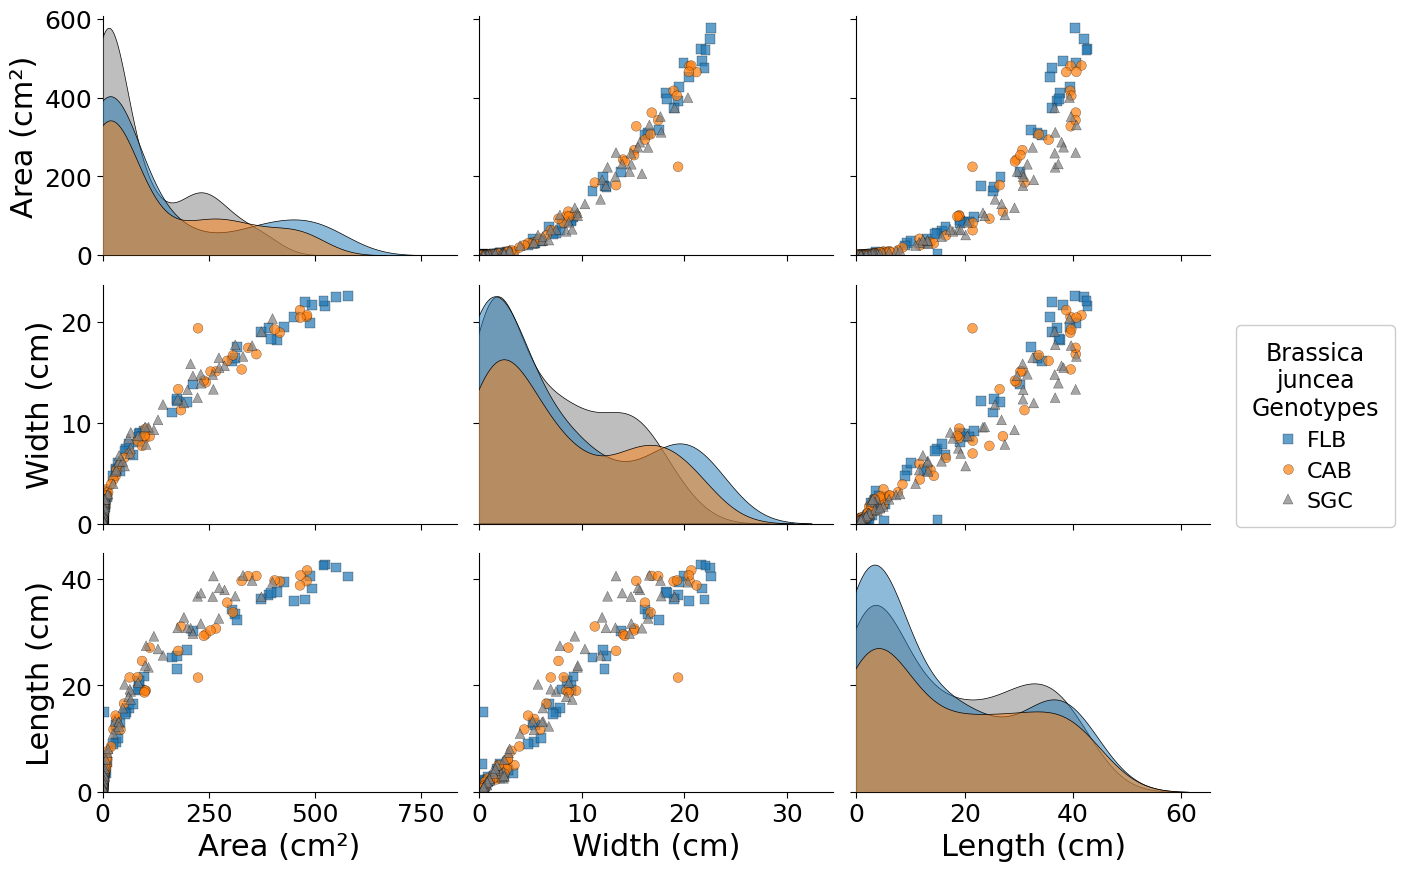

In [ ]:
# Scatterplot matrix (pairplot) for leaf area data, with x-axis starting at 0
def plot_scatter_matrix(df, columns, hue='Cultivar', legend_title='Brassica\njuncea\nGenotypes', figsize=(15, 9)):
    """
    Plots a scatterplot matrix (pairplot) for the given DataFrame.
    X axes start at 0 and do not go negative.
    Args:
        df (pd.DataFrame): DataFrame with numeric columns to plot.
        columns (list): List of columns to include in the matrix. If None, all numeric columns are used.
        hue (str): Column to color by (default 'Cultivar').
        legend_title (str): Title shown on the legend. Use `/n` to insert line breaks.
        figsize (tuple): Tuple specifying the figure size (width, height).
    """
    if columns is None:
        columns = df.select_dtypes(include='number').columns.tolist()
    display_names = {
        'Leaf_Area': 'Area (cm²)',
        'Leaf_Width': 'Width (cm)',
        'Leaf_Length': 'Length (cm)',
    }
    plot_df = df.copy()
    rename_map = {col: display_names[col] for col in columns if col in display_names}
    if rename_map:
        plot_df = plot_df.rename(columns=rename_map)
        plot_columns = [rename_map.get(col, col) for col in columns]
    else:
        plot_columns = columns

    markers = {genotype: marker for genotype, marker in zip(plot_df[hue].unique(), ['o', 's', '^', 'D', 'v', 'P'])}

    # Create the pairplot with larger fonts
    with sns.plotting_context('talk', font_scale=1.6, rc={'axes.linewidth': 0.8, 'xtick.major.width': 0.8, 'ytick.major.width': 0.8}):
        g = sns.pairplot(plot_df, vars=plot_columns, hue=hue, palette=color,
                         markers=[markers[k] for k in plot_df[hue].unique()],
                         diag_kws={
                            'color': 'coral',
                            'edgecolor': 'k',
                            'lw': 0.5,
                            'alpha': 0.5,
                            'fill': True
                            }, 
                         plot_kws={'alpha': 0.7, 'edgecolor': 'k', 'linewidth': 0.25, 's': 50})
    g.fig.set_size_inches(figsize)
    g.fig.subplots_adjust(right=0.82)
    for ax in g.axes.flatten():
        if ax is not None:
            ax.set_xlim(left=0)
            ax.set_ylim(bottom=0)
            ax.tick_params(axis='both', which='major', labelsize=18, width=0.8, length=4)
            ax.tick_params(axis='both', which='minor', labelsize=16, width=0.6, length=2)
            ax.xaxis.label.set_size(22)
            ax.yaxis.label.set_size(22)
            ax.title.set_fontsize(22)
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)
    if g._legend is not None:
        legend_order = ['FLB', 'CAB', 'SGC']
        handles, labels = g._legend.legend_handles, [text.get_text() for text in g._legend.get_texts()]
        handle_map = dict(zip(labels, handles))
        ordered_labels = [label for label in legend_order if label in handle_map]
        ordered_labels += [label for label in labels if label not in ordered_labels]
        ordered_handles = [handle_map[label] for label in ordered_labels]
        g._legend.remove()
        legend = g.fig.legend(
            ordered_handles,
            ordered_labels,
            title=legend_title,
            loc='center left',
            bbox_to_anchor=(0.82, 0.5),
            frameon=True,
            fontsize=16,
            title_fontsize=17,
            handletextpad=0.35,
            labelspacing=0.45,
            borderpad=0.7,
            handlelength=1.0,
            handleheight=0.8,
        )
        legend.set_title(legend_title, prop={'size': 17})
        legend.get_title().set_ha('center')
        legend.get_title().set_multialignment('center')
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_edgecolor('0.8')
        legend.get_frame().set_alpha(1.0)
    plt.tight_layout(rect=[0, 0, 0.82, 0.98])
    plt.show()
# Example usage:
plot_scatter_matrix(combined_df, columns=['Leaf_Area', 'Leaf_Width', 'Leaf_Length'])

### ORDINARY LEAST SQUARES ###

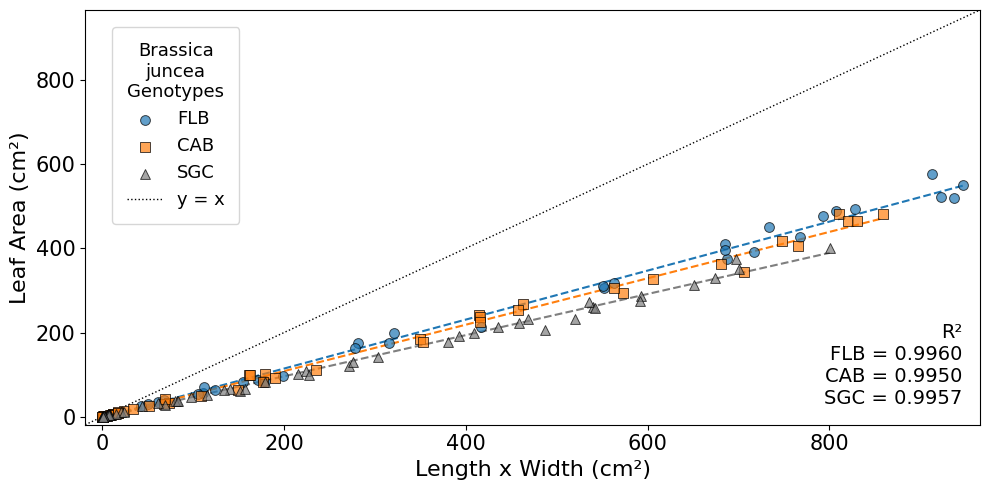

Cultivar R^2 (Pearson r squared):
  FLB: R^2 = 0.996
  CAB: R^2 = 0.995
  SGC: R^2 = 0.996


In [ ]:
# Scatter plot of LxW vs Leaf_Area by Cultivar, with regression line
def plot_lxw_vs_leaf_area_by_cultivar(df):
    """
    Plots a scatter plot of LxW vs Leaf_Area for each Cultivar, draws a 1:1 black line
    across the full plot, and shows Pearson-based R^2 values for each cultivar in the plot.
    Args:
        df (pd.DataFrame): DataFrame with 'LxW', 'Leaf_Area', and 'Cultivar' columns.
    """
    valid = df[['LxW', 'Leaf_Area']].dropna()
    if valid.empty:
        print('No numeric LxW/Leaf_Area data to plot.')
        return
    global_min = min(valid['LxW'].min(), valid['Leaf_Area'].min())
    global_max = max(valid['LxW'].max(), valid['Leaf_Area'].max())
    pad = 0.02 * (global_max - global_min) if global_max > global_min else 0.1 * max(global_max, 1)
    min_plot = global_min - pad
    max_plot = global_max + pad
    fig, ax = plt.subplots(figsize=(10, 5))
    cultivars = df['Cultivar'].dropna().unique()
    r2_records = []

    marker_map = {cultivar: marker for cultivar, marker in zip(cultivars, ['o', 's', '^', 'D', 'v', 'P'])}

    # 1:1 line across the entire plot range
    xx_full = np.linspace(min_plot, max_plot, 200)
    #ax.plot(xx_full, xx_full, color='black', linestyle=':', linewidth=1, zorder=1)
    for cultivar in cultivars:
        sub_df = df[df['Cultivar'] == cultivar][['LxW', 'Leaf_Area']].dropna()
        if sub_df.empty:
            continue
        x = sub_df['LxW'].to_numpy()
        y = sub_df['Leaf_Area'].to_numpy()
        r2 = np.nan
        if len(x) > 1:
            r = np.corrcoef(x, y)[0, 1]
            r2 = r ** 2
        r2_records.append((cultivar, r2))
        ax.scatter(
            x,
            y,
            label=cultivar,
            color=color.get(cultivar, None),
            alpha=0.7,
            edgecolor='k',
            linewidths=.7,
            s=50,
            marker=marker_map[cultivar],
            zorder=3,
        )
        if len(x) > 1:
            slope, intercept = np.polyfit(x, y, 1)
            x_vals = np.linspace(x.min(), x.max(), 100)
            y_vals = slope * x_vals + intercept
            ax.plot(x_vals, y_vals, color=color.get(cultivar, None), linestyle='--', linewidth=1.5, zorder=2)
    ax.set_xlim(min_plot, max_plot)
    ax.set_ylim(min_plot, max_plot)
    ax.set_aspect('auto')
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.set_xlabel('Length x Width (cm²)', fontsize=16)
    ax.set_ylabel('Leaf Area (cm²)', fontsize=16)
    # ax.set_title('Ordinary Least Squares Leaf Area vs LxW by Cultivar')
    #ax.legend(title='Cultivar', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    ax.plot(xx_full, xx_full, color='black', linestyle=':', linewidth=1, zorder=1, label='y = x')
    #legend = ax.legend(title='Brassica\njuncea\nGenotypes', loc='upper left', bbox_to_anchor=(0.02, 0.98), frameon=True, fontsize=11, title_fontsize=11)
    legend = ax.legend(title='Brassica\njuncea\nGenotypes', loc='upper left', bbox_to_anchor=(0.02, 0.98), frameon=True, fontsize=13, title_fontsize=13, borderpad=0.8)
    legend.get_title().set_ha('center')
    legend.get_title().set_multialignment('center')

    if r2_records:
        r2_lines = ["R²"]
        for cultivar, r2 in r2_records:
            if np.isnan(r2):
                r2_lines.append(f"{cultivar} = n<2")
            else:
                r2_lines.append(f"{cultivar} = {r2:.4f}")
        ax.text(
            0.98, 0.04,
            "\n".join(r2_lines),
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=14,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none')
        )
    fig.tight_layout()
    plt.show()
    print('Cultivar R^2 (Pearson r squared):')
    for cult, r2 in r2_records:
        if np.isnan(r2):
            print(f'  {cult}: n<2 (R^2 N/A)')
        else:
            print(f'  {cult}: R^2 = {r2:.3f}')
# Example usage:
plot_lxw_vs_leaf_area_by_cultivar(GatorLeaf_df)

### SCATTER PLOT + ORDINARY LEAST SQUARES ###

n = 181
Deming slope = 0.995741 (95% CI 0.992928 to 0.998468)
Deming intercept = -0.139794 (95% CI -0.322093 to 0.041430)
Lin's CCC = 0.999925 (95% CI 0.999893 to 0.999954)
MAE = 1.025 cm², RMSE = 1.918 cm²


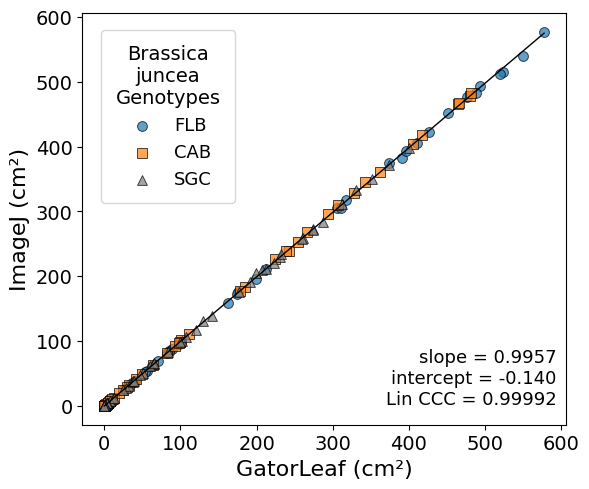

In [250]:
# -------- Lin's CCC --------
def lin_ccc(x, y):
    x = np.asarray(x); y = np.asarray(y)
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    sx, sy = np.sqrt(vx), np.sqrt(vy)
    r = np.corrcoef(x, y)[0, 1]
    return (2 * r * sx * sy) / (vx + vy + (mx - my) ** 2)

def bootstrap_ci(func, x, y, n_boot=3000, seed=123, alpha=0.05):
    rng = np.random.default_rng(seed)
    n = len(x)
    vals = [func(x[idx := rng.integers(0, n, size=n)], y[idx]) for _ in range(n_boot)]
    return np.percentile(vals, [100 * alpha / 2, 100 * (1 - alpha / 2)])

# -------- Deming regression --------
def deming_regression(x, y, lambda_ratio=1.0):
    x = np.asarray(x); y = np.asarray(y)
    mx, my = np.mean(x), np.mean(y)
    Sxx = np.sum((x - mx) ** 2) / (len(x) - 1)
    Syy = np.sum((y - my) ** 2) / (len(y) - 1)
    Sxy = np.sum((x - mx) * (y - my)) / (len(x) - 1)
    D = Syy - lambda_ratio * Sxx
    slope = (D + np.sqrt(D**2 + 4 * lambda_ratio * Sxy**2)) / (2 * Sxy)
    return slope, my - slope * mx

def deming_bootstrap_ci(x, y, lambda_ratio=1.0, n_boot=3000, seed=123, alpha=0.05):
    rng = np.random.default_rng(seed)
    n = len(x)
    fits = [deming_regression(x[idx := rng.integers(0, n, size=n)], y[idx], lambda_ratio) for _ in range(n_boot)]
    slopes, intercepts = zip(*fits)
    return (np.percentile(slopes, [100 * alpha / 2, 100 * (1 - alpha / 2)]),
            np.percentile(intercepts, [100 * alpha / 2, 100 * (1 - alpha / 2)]))

# -------- MAE / RMSE --------
def mae_rmse(x, y):
    d = np.asarray(y) - np.asarray(x)
    return np.mean(np.abs(d)), np.sqrt(np.mean(d**2))

# -------- Plot --------
def plot_deming(x, y, slope, intercept, cultivars=None, title="", ccc=None):
    x = np.asarray(x); y = np.asarray(y)
    fig, ax = plt.subplots(figsize=(6, 5))

    marker_list = ['o', 's', '^', 'D', 'v', 'P']
    if cultivars is not None:
        cultivars = np.asarray(cultivars)
        unique_cultivars = list(dict.fromkeys(cultivars))
        marker_map = {lab: marker_list[i] for i, lab in enumerate(unique_cultivars)}
        for lab in unique_cultivars:
            mask = cultivars == lab
            ax.scatter(
                x[mask], y[mask],
                s=50, alpha=0.7, edgecolor='k', linewidths=0.7,
                color=color.get(lab, '#7f7f7f'),
                marker=marker_map[lab],
                label=str(lab), zorder=5,
            )
        legend = ax.legend(
            title='Brassica\njuncea\nGenotypes',
            loc='upper left', bbox_to_anchor=(0.02, 0.98),
            frameon=True, fontsize=13, title_fontsize=14, borderpad=0.8,
        )
        legend.get_title().set_ha('center')
        legend.get_title().set_multialignment('center')
    else:
        ax.scatter(x, y, s=50, alpha=0.7, edgecolor='k', 
                   linewidths=0.7, zorder=5, marker='o')
        

    xx = np.linspace(np.min(x), np.max(x), 200)
    ax.plot(xx, intercept + slope * xx, color='black', lw=1, zorder=10)
    ax.set_xlabel('GatorLeaf (cm²)', fontsize=16)
    ax.set_ylabel('ImageJ (cm²)', fontsize=16)
    #ax.set_title(title, fontsize=17)
    ax.tick_params(axis='both', which='major', labelsize=14)
    txt = f"slope = {slope:.4f}\nintercept = {intercept:.3f}"
    if ccc is not None:
        txt += f"\nLin CCC = {ccc:.5f}"
    ax.text(0.98, 0.04, txt, transform=ax.transAxes, ha='right', va='bottom',
            fontsize=13, bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))
    plt.tight_layout()
    return fig, ax

# -------- Run --------
x = Stats_LA['GatorLeaf'].to_numpy()
y = Stats_LA['ImageJ'].to_numpy()
cultivars = Stats_LA['Cultivar'].to_numpy()

slope, intercept = deming_regression(x, y)
slope_ci, intercept_ci = deming_bootstrap_ci(x, y)
ccc_val = lin_ccc(x, y)
ccc_ci = bootstrap_ci(lin_ccc, x, y)
mae, rmse = mae_rmse(x, y)

print(f"n = {len(x)}")
print(f"Deming slope = {slope:.6f} (95% CI {slope_ci[0]:.6f} to {slope_ci[1]:.6f})")
print(f"Deming intercept = {intercept:.6f} (95% CI {intercept_ci[0]:.6f} to {intercept_ci[1]:.6f})")
print(f"Lin's CCC = {ccc_val:.6f} (95% CI {ccc_ci[0]:.6f} to {ccc_ci[1]:.6f})")
print(f"MAE = {mae:.3f} cm², RMSE = {rmse:.3f} cm²")

plot_deming(x, y, slope, intercept, cultivars=cultivars, ccc=ccc_val)
plt.show()

### LM REGRESSION STATS ###

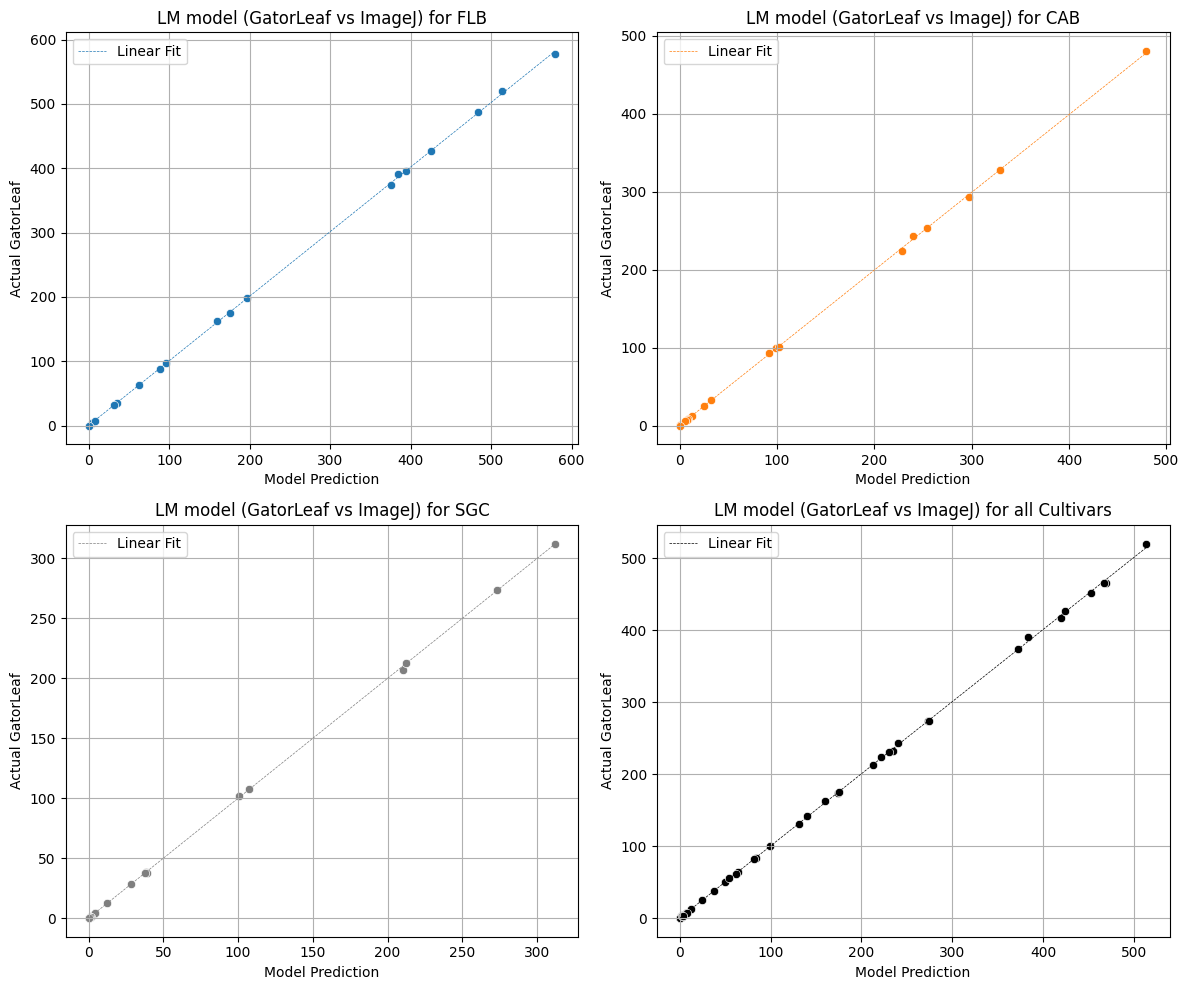

In [ ]:
# Linear Regression (Source Only with Cultivar distinction)
# Create and train Linear Model on Leaf Area data on only Source (Compare ImageJ and GatorLeaf only)

# Replace discrete str values with numeric str
Stats_FLB = Stats_LA[Stats_LA['Cultivar'] == 'FLB']
Stats_CAB = Stats_LA[Stats_LA['Cultivar'] == 'CAB']
Stats_SGC = Stats_LA[Stats_LA['Cultivar'] == 'SGC']

Final_FLB = Stats_FLB.drop(columns=['Cultivar', 'Sample_Num', 'Leaf_Num']).dropna()
Final_CAB = Stats_CAB.drop(columns=['Cultivar', 'Sample_Num', 'Leaf_Num']).dropna()
Final_SGC = Stats_SGC.drop(columns=['Cultivar', 'Sample_Num', 'Leaf_Num']).dropna()

Final_Stats = Stats_LA.drop(columns=['Cultivar', 'Sample_Num', 'Leaf_Num']).dropna()

# Separate out the testing and training data 
# X_var = Predictor
# Y_Var = Variable of interest
X_SGC = Final_SGC[['ImageJ']]  # Ensure X_var is a DataFrame
Y_SGC = Final_SGC['GatorLeaf']

X_CAB = Final_CAB[['ImageJ']]  # Ensure X_var is a DataFrame
Y_CAB = Final_CAB['GatorLeaf']

X_FLB = Final_FLB[['ImageJ']]  # Ensure X_var is a DataFrame
Y_FLB = Final_FLB['GatorLeaf']

X_Stats = Final_Stats[['ImageJ']]  # Ensure X_var is a DataFrame
Y_Stats = Final_Stats['GatorLeaf']

# Create Testing and Training data using "train_test_split"
X_FLB_train, X_FLB_test, Y_FLB_train, Y_FLB_test = train_test_split(X_FLB, Y_FLB, test_size=0.3, random_state=123)
X_CAB_train, X_CAB_test, Y_CAB_train, Y_CAB_test = train_test_split(X_CAB, Y_CAB, test_size=0.3, random_state=123)
X_SGC_train, X_SGC_test, Y_SGC_train, Y_SGC_test = train_test_split(X_SGC, Y_SGC, test_size=0.3, random_state=123)
X_Stats_train, X_Stats_test, Y_Stats_train, Y_Stats_test = train_test_split(X_Stats, Y_Stats, test_size=0.3, random_state=123)

## 
lm = LinearRegression()

## Train the model with the training data (Given X_var, Y_svar should be true)
lm_FLB = lm.fit(X_FLB_train, Y_FLB_train)
lm_CAB = lm.fit(X_CAB_train, Y_CAB_train)
lm_SGC = lm.fit(X_SGC_train, Y_SGC_train)
lm_Stats = lm.fit(X_Stats_train, Y_Stats_train)

## List out variable coefficients from each variable for the trained model
coeff_FLB = pd.DataFrame(lm_FLB.coef_, X_FLB.columns, columns=['Coef'])
coeff_CAB = pd.DataFrame(lm_CAB.coef_, X_CAB.columns, columns=['Coef'])
coeff_SGC = pd.DataFrame(lm_SGC.coef_, X_SGC.columns, columns=['Coef'])
coeff_Stats = pd.DataFrame(lm_Stats.coef_, X_Stats.columns, columns=['Coef'])
# print(cdf)

## Model Predictions (Source Only)
pred_FLB = lm_FLB.predict(X_FLB_test)
pred_CAB = lm_CAB.predict(X_CAB_test)
pred_SGC = lm_SGC.predict(X_SGC_test)
pred_Stats = lm_Stats.predict(X_Stats_test)
# print(predictions)

## Create a scatterplot of GatorLeaf data vs model trained on ImageJ data
## (How closely related are the GatorLeaf data and the model trained on ImageJ data?)

plot_data = [
    (pred_FLB, Y_FLB_test, "FLB", "LM model (GatorLeaf vs ImageJ) for FLB"),
    (pred_CAB, Y_CAB_test, "CAB", "LM model (GatorLeaf vs ImageJ) for CAB"),
    (pred_SGC, Y_SGC_test, "SGC", "LM model (GatorLeaf vs ImageJ) for SGC"),
    (pred_Stats, Y_Stats_test, "All", "LM model (GatorLeaf vs ImageJ) for all Cultivars")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (pred, y_test, label, title) in enumerate(plot_data):
    color = color.get(label, '#1f77b4') if label != 'All' else 'black'
    sns.scatterplot(x=pred, y=y_test, ax=axes[i], color=color)
    # Plot linear regression line
    if len(pred) > 1:
        slope, intercept = np.polyfit(pred, y_test, 1)
        x_vals = np.linspace(min(pred), max(pred), 100)
        y_vals = slope * x_vals + intercept
        axes[i].plot(x_vals, y_vals, color=color, linestyle='--', linewidth=0.5, label='Linear Fit')
    axes[i].set_title(title)
    axes[i].set_xlabel("Model Prediction")
    axes[i].set_ylabel("Actual GatorLeaf")
    axes[i].grid(True)
    axes[i].legend()
plt.tight_layout()
plt.show()


In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# Build a DataFrame with error metrics for each variation
metrics = []
variations = [
    ("FLB", Y_FLB_test, pred_FLB),
    ("CAB", Y_CAB_test, pred_CAB),
    ("SGC", Y_SGC_test, pred_SGC),
    ("Stats", Y_Stats_test, pred_Stats)
 ]

for label, y_true, y_pred in variations:
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    metrics.append({
        "Variation": label,
        "Mean Absolute Error": mae,
        "Mean Squared Error": mse,
        "RMSE": rmse
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

  Variation  Mean Absolute Error  Mean Squared Error      RMSE
0       FLB             1.779233            6.915485  2.629731
1       CAB             1.064763            2.737732  1.654609
2       SGC             0.464759            0.768654  0.876729
3     Stats             0.925818            3.000932  1.732320


### BLAND-ALTMAN STATS ###

Bias (Mean Difference): 0.66 cm²
Standard Deviation of Differences: 1.81 cm²
95% Confidence Interval Limits: [-2.89, 4.20] cm²


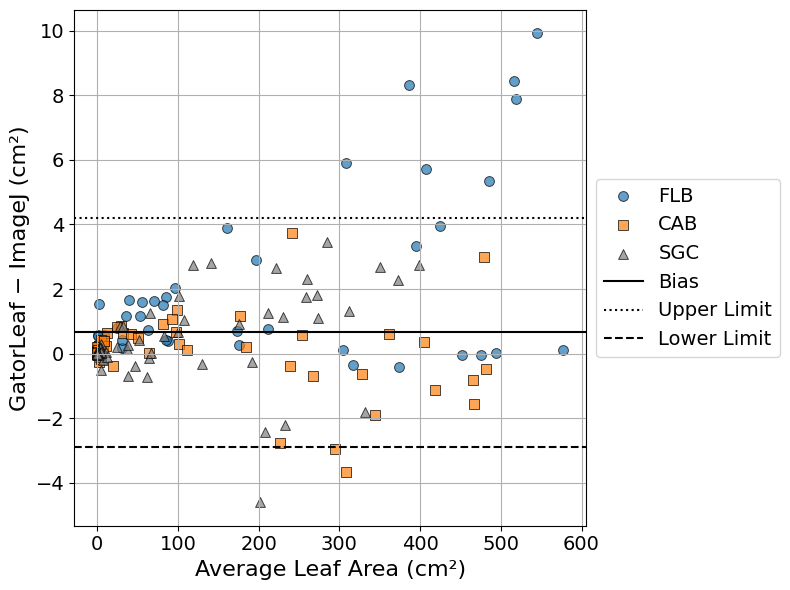

In [ ]:
# Plot Difference vs Average for GatorLeaf vs ImageJ Leaf Area data (Bland-Altman Plot)
Stats_LA_bias = Stats_LA['Difference'].mean()
print(f"Bias (Mean Difference): {Stats_LA_bias:.2f} cm²")
Stats_LA_bias_sd = Stats_LA['Difference'].std()
print(f"Standard Deviation of Differences: {Stats_LA_bias_sd:.2f} cm²")
Stats_LA_bias_lower_limit = Stats_LA_bias - 1.96 * Stats_LA_bias_sd
Stats_LA_bias_upper_limit = Stats_LA_bias + 1.96 * Stats_LA_bias_sd
print(f"95% Confidence Interval Limits: [{Stats_LA_bias_lower_limit:.2f}, {Stats_LA_bias_upper_limit:.2f}] cm²")

marker_list = ['o', 's', '^', 'D', 'v', 'P']
unique_cultivars = list(dict.fromkeys(Stats_LA['Cultivar']))
marker_map = {lab: marker_list[i] for i, lab in enumerate(unique_cultivars)}

plt.figure(figsize=(8, 6))
for cultivar in unique_cultivars:
    cultivar_data = Stats_LA[Stats_LA['Cultivar'] == cultivar]
    plt.scatter(
        cultivar_data['Avg'],
        cultivar_data['Difference'],
        alpha=0.7,
        label=cultivar,
        edgecolor='k',
        linewidths=0.7,
        s=50,
        color=color.get(cultivar, '#1f77b4'),
        marker=marker_map[cultivar]
    )
plt.axhline(Stats_LA_bias, color='black', linestyle='-', label='Bias')
plt.axhline(Stats_LA_bias_upper_limit, color='black', linestyle=':', label='Upper Limit')
plt.axhline(Stats_LA_bias_lower_limit, color='black', linestyle='--', label='Lower Limit')
plt.xlabel('Average Leaf Area (cm²)', fontsize=16)
plt.ylabel('GatorLeaf − ImageJ (cm²)', fontsize=16)
#plt.title('Bland-Altman Plot for Leaf Area Measurements', fontsize=16)
plt.legend(title='', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14, title_fontsize=14)
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

### OTHER STATS ###

In [92]:
# Calculate the average and total leaf area per image for GatorLeaf and ImageJ
leaf_area_stats = Stats_LA.groupby(['Sample_Num', 'Cultivar']).agg(
    Avg_GL=('GatorLeaf', 'mean'),
    Avg_IJ=('ImageJ', 'mean'),
    Total_GL=('GatorLeaf', 'sum'),
    Total_IJ=('ImageJ', 'sum')
).reset_index()

leaf_area_stats["Error"] = leaf_area_stats["Avg_GL"] - leaf_area_stats["Avg_IJ"]

Leaf_Avg = leaf_area_stats['Avg_GL'].mean()
Leaf_SD = leaf_area_stats['Avg_IJ'].std()

Total_Avg = leaf_area_stats['Total_GL'].mean()
Total_SD = leaf_area_stats['Total_GL'].std()


# Display the result
print(leaf_area_stats)
print(f"Avg Leaf Area: {Leaf_Avg} ± {Leaf_SD}")
print(f"Avg Total Leaf Area: {Total_Avg} ± {Total_SD}")

    Sample_Num Cultivar      Avg_GL      Avg_IJ   Total_GL  Total_IJ     Error
0            4      CAB   98.980738   99.124308  1286.7496  1288.616 -0.143569
1           27      FLB  169.489088  166.060375  2711.8254  2656.966  3.428713
2           31      CAB  140.568021  139.708786  1967.9523  1955.923  0.859236
3           34      FLB   97.677077   97.445538  1269.8020  1266.792  0.231538
4           47      SGC   86.387022   85.220056  1554.9664  1533.961  1.166967
5           51      FLB  125.543500  123.896833  2259.7830  2230.143  1.646667
6           62      SGC  110.149688  109.504529  1872.5447  1861.577  0.645159
7           65      CAB  114.933379  115.203500  1609.0673  1612.849 -0.270121
8           83      CAB  154.149054  154.308615  2003.9377  2006.012 -0.159562
9           92      SGC   85.385880   86.306467  1280.7882  1294.597 -0.920587
10         100      FLB  186.768136  186.678429  2614.7539  2613.498  0.089707
11         115      SGC   94.316488   93.847000  150

### DEMING REGRESSION + LINs CCC AT IMAGE LEVEL ###

In [93]:
## Calculate the average leaf area per image for GatorLeaf and ImageJ, and compute error metrics
## Using RMSE 

# Compute image totals grouped by Sample_Num and Cultivar
tot = (Stats_LA.groupby(["Sample_Num", "Cultivar"])[["GatorLeaf", "ImageJ"]]
             .sum()
             .rename(columns={"GatorLeaf": "x", "ImageJ": "y"}))
x_tot = tot["x"].to_numpy()
y_tot = tot["y"].to_numpy()

# Agreement on image totals
slope_t, int_t = deming_regression(x_tot, y_tot, lambda_ratio=1.0)
slope_ci_t, int_ci_t = deming_bootstrap_ci(x_tot, y_tot, lambda_ratio=1.0)
ccc_t = lin_ccc(x_tot, y_tot); ccc_ci_t = bootstrap_ci(lin_ccc, x_tot, y_tot)
mae_t = np.mean(np.abs(y_tot - x_tot))
rmse_t = np.sqrt(np.mean((y_tot - x_tot)**2))
nrmse_t = rmse_t / np.mean(y_tot)
coverage_5 = np.mean(np.abs(y_tot - x_tot) / y_tot <= 0.02)

print(f"Totals n={len(x_tot)}")
print(f"Deming slope={slope_t:.4f} ({slope_ci_t[0]:.4f}–{slope_ci_t[1]:.4f}), "
        f"intercept={int_t:.3f} ({int_ci_t[0]:.3f}–{int_ci_t[1]:.3f})")
print(f"CCC={ccc_t:.6f} ({ccc_ci_t[0]:.6f}–{ccc_ci_t[1]:.6f})")
print(f"MAE_total={mae_t:.2f} cm², RMSE_total={rmse_t:.2f} cm², NRMSE_total={100*nrmse_t:.2f}%")
print(f"% images within ±2% of ImageJ total: {100*coverage_5:.1f}%")

Totals n=12
Deming slope=0.9774 (0.9583–1.0010), intercept=31.396 (-8.267–64.115)
CCC=0.999117 (0.998063–0.999807)
MAE_total=13.48 cm², RMSE_total=20.15 cm², NRMSE_total=1.11%
% images within ±2% of ImageJ total: 91.7%


### CORRELATION & REGRESSION STATS ###

In [94]:
## Calculate all necessary values for conducting regression
Correlation_LA = Stats_LA.copy()

## GatorLeaf == X, ImageJ == Y
X_sum = sum(Correlation_LA['GatorLeaf'])
X_avg = Correlation_LA['GatorLeaf'].mean()
Y_sum = sum(Correlation_LA['ImageJ'])
Y_avg = Correlation_LA['ImageJ'].mean()

Correlation_LA["X-X_avg"] = Correlation_LA['GatorLeaf'] - X_avg        
Correlation_LA["Y-Y_avg"] = Correlation_LA['ImageJ'] - Y_avg           
Correlation_LA["(X-X_avg)^2"] = np.square(Correlation_LA["X-X_avg"])
Correlation_LA["(Y-Y_avg)^2"] = np.square(Correlation_LA["Y-Y_avg"])

X_Xavg = sum(Correlation_LA["X-X_avg"])
Y_Yavg = sum(Correlation_LA["Y-Y_avg"])
X_Xavg_sq = sum(Correlation_LA["(X-X_avg)^2"])
Y_Yavg_sq = sum(Correlation_LA["(Y-Y_avg)^2"])
SSx = sum(Correlation_LA["(X-X_avg)^2"])
SSy = sum(Correlation_LA["(Y-Y_avg)^2"])

Correlation_LA["SPxy"] = Correlation_LA["X-X_avg"] * Correlation_LA["Y-Y_avg"]

SPxy = sum(Correlation_LA["SPxy"])

b = SPxy / SSx
a = (Y_avg) - (b * X_avg)

Correlation_LA["Y_hat"] = a + (b * Correlation_LA['GatorLeaf'])
Correlation_LA["Y_hat - Y_avg"] = Correlation_LA["Y_hat"] - Y_avg
Correlation_LA["(Y_hat - Y_avg)^2"] = np.square(Correlation_LA["Y_hat - Y_avg"])
Correlation_LA["Yi - Y_hat"] = Correlation_LA['ImageJ'] - Correlation_LA["Y_hat"]
Correlation_LA["(Yi - Y_hat)^2"] = np.square(Correlation_LA["Yi - Y_hat"])

Yhat_Yavg = sum(Correlation_LA["Y_hat - Y_avg"])
SSreg = sum(Correlation_LA["(Y_hat - Y_avg)^2"])
Y_Yhat = sum(Correlation_LA["Yi - Y_hat"])
SSerror = sum(Correlation_LA["(Yi - Y_hat)^2"])
Check = SSreg + SSerror

r = (SPxy / np.sqrt(SSx * SSy))    # Correlation Coefficient
R_sq = (SSreg / SSy)    # Correlation of Determination
#R_sq = np.square(r)    # Correlation of Determination

print("X Sum: ", X_sum)             
print("X Avg: ", X_avg)
print("Y Sum: ", Y_sum)            
print("Y Avg: ", Y_avg)
print("X-X_avg Sum", X_Xavg)       # Should be ~0
print("Y-Y_avg Sum", Y_Yavg)       # Should be ~0
print("X-X_avg_sq Sum", X_Xavg_sq)       
print("Y-Y_avg_sq Sum", Y_Yavg_sq)       
print("SSx: ", SSx)
print("SSy: ", SSy)
print("SPxy: ", SPxy)
print("b: ", b)
print("a: ", a)
print("Predicted Y (Y_hat) - Avg Y Sum: ", Yhat_Yavg)       # Should be ~0
print("Sum of Squares Regression (Y_hat - Y_avg_sq Sum): ", SSreg)    
print("Actual Y - Predicted Y (Y_hat): ", Y_Yhat)          # Should be ~0
print("Sum of Squares Error Actual (Y - Y_hat sq Sum): ", SSerror)
print("Best Fit Line: ", "Y =", a, "+", "(", b, ")X")
# print("Check SSerror + SSreg = SSy:", Check, " = ", SSy)
print("Correlation Coefficient: ", r)
print("Correlation of Determination: ", R_sq)

Correlation_LA.tail()

X Sum:  21941.2343
X Avg:  121.22228895027627
Y Sum:  21822.486
Y Avg:  120.56622099447515
X-X_avg Sum -3.943512183468556e-12
Y-Y_avg Sum -1.1795009413617663e-12
X-X_avg_sq Sum 4427567.548126378
Y-Y_avg_sq Sum 4389936.81988916
SSx:  4427567.548126378
SSy:  4389936.81988916
SPxy:  4408458.108472542
b:  0.9956839868740291
a:  -0.13287096553149524
Predicted Y (Y_hat) - Avg Y Sum:  -3.346656285430072e-12
Sum of Squares Regression (Y_hat - Y_avg_sq Sum):  4389431.145411082
Actual Y - Predicted Y (Y_hat):  2.2118279430216603e-12
Sum of Squares Error Actual (Y - Y_hat sq Sum):  505.67447807824254
Best Fit Line:  Y = -0.13287096553149524 + ( 0.9956839868740291 )X
Correlation Coefficient:  0.9999424036083255
Correlation of Determination:  0.9998848105339951


,Leaf_Num,Sample_Num,Cultivar,GatorLeaf,ImageJ,Difference,Avg,X-X_avg,Y-Y_avg,(X-X_avg)^2,(Y-Y_avg)^2,SPxy,Y_hat,Y_hat - Y_avg,(Y_hat - Y_avg)^2,Yi - Y_hat,(Yi - Y_hat)^2
176,5,115,SGC,176.4928,175.586,0.9068,176.0394,55.270511,55.019779,3054.829392,3027.176082,3040.971303,175.598184,55.031963,3028.516929,-0.012184,0.000148
177,6,115,SGC,99.8358,99.153,0.6828,99.4944,-21.386489,-21.413221,457.381910,458.526033,457.953614,99.272036,-21.294185,453.442297,-0.119036,0.014170
178,7,115,SGC,66.0418,66.034,0.0078,66.0379,-55.180489,-54.532221,3044.886361,2973.763127,3009.114618,65.623892,-54.942329,3018.659542,0.410108,0.168189
179,8,115,SGC,47.1656,47.559,-0.3934,47.3623,-74.056689,-73.007221,5484.393178,5330.054317,5406.673056,46.829162,-73.737059,5437.153915,0.729838,0.532664
180,9,115,SGC,38.5470,38.281,0.2660,38.4140,-82.675289,-82.285221,6835.203403,6770.857594,6802.954422,38.247760,-82.318461,6776.329074,0.033240,0.001105
